In [1]:
import numpy as np
import glob
from functools import reduce
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def importAndFormat(path):
    df = pd.read_csv(path, parse_dates=['date'])
    df = df.dropna()
    df['date'] = df['date'].dt.year
    df = df.drop_duplicates(subset='date', keep='first')
    return df

def dataframeMerger(df_array):
    df_merged = reduce(lambda left, right: left.merge(right, on='date'), df_array)
    df_merged = df_merged[df_merged['date'] >= 2011]
    return df_merged

In [3]:
path = '../Data/Economic_data'

    # National CPI
df_CPI_NATIONAL = importAndFormat(f'{path}/CPI_national.csv')

    # Wisconsin CPI concatenated
df_CPI_WI_CHI = importAndFormat(f'{path}/CPI_WI_Chicago.csv')
df_CPI_WI_MIL = importAndFormat(f'{path}/CPI_WI_Milwaukee.csv')
df_CPI_WI_MIN = importAndFormat(f'{path}/CPI_WI_Minneapolis.csv')
df_array_WI = [df_CPI_WI_CHI, df_CPI_WI_MIL, df_CPI_WI_MIN]
df_CPI_WI = dataframeMerger(df_array_WI)
df_CPI_WI['cpi_WI_avg'] = df_CPI_WI[['cpi_WI_CHI', 'cpi_WI_MIL', 'cpi_WI_MIN']].mean(axis=1).round(3)

    # Texas CPI concatenated
df_CPI_TX_DAL = importAndFormat(f'{path}/CPI_TX_Dallas.csv')
df_CPI_TX_HOU = importAndFormat(f'{path}/CPI_TX_Houston.csv')
df_array_TX = [df_CPI_TX_DAL, df_CPI_TX_HOU]
df_CPI_TX = dataframeMerger(df_array_TX)
df_CPI_TX['cpi_TX_avg'] = df_CPI_TX[['cpi_TX_DAL', 'cpi_TX_HOU']].mean(axis=1).round(3)

    # California CPI concatenated
df_CPI_CA_LA = importAndFormat(f'{path}/CPI_CA_LosAngeles.csv')
df_CPI_CA_SD = importAndFormat(f'{path}/CPI_CA_SanDiego.csv')
df_CPI_CA_SF = importAndFormat(f'{path}/CPI_CA_SanFrancisco.csv')
df_array_CA = [df_CPI_CA_LA, df_CPI_CA_SD, df_CPI_CA_SF]
df_CPI_CA = dataframeMerger(df_array_CA)
df_CPI_CA['cpi_CA_avg'] = df_CPI_CA[['cpi_CA_LA', 'cpi_CA_SD', 'cpi_CA_SF']].mean(axis=1).round(3)


In [4]:
df_CPI_WI.head()

,date,cpi_WI_CHI,cpi_WI_MIL,cpi_WI_MIN,cpi_WI_avg
0,2011,215.155,216.934,219.339,217.143
1,2012,219.585,221.143,224.459,221.729
2,2013,222.251,225.061,228.811,225.374
3,2014,225.027,227.820,232.013,228.287
4,2015,225.852,226.602,230.567,227.674


In [5]:
df_array_ALL = [df_CPI_NATIONAL,df_CPI_WI, df_CPI_TX, df_CPI_CA]
df_CPI_ALL = dataframeMerger(df_array_ALL)

In [6]:
df_CPI_ALL['cpi_ALL_avg'] = df_CPI_ALL[['cpi_WI_avg', 'cpi_TX_avg', 'cpi_CA_avg']].mean(axis=1).round(3)

df_CPI_ALL.head(10)

,date,cpi_national,cpi_WI_CHI,cpi_WI_MIL,cpi_WI_MIN,cpi_WI_avg,cpi_TX_DAL,cpi_TX_HOU,cpi_TX_avg,cpi_CA_LA,cpi_CA_SD,cpi_CA_SF,cpi_CA_avg,cpi_ALL_avg
0,2011,221.187,215.155,216.934,219.339,217.143,203.199,197.224,200.212,228.652,252.910,229.981,237.181,218.179
1,2012,227.842,219.585,221.143,224.459,221.729,209.203,204.291,206.747,233.441,256.961,236.880,242.427,223.634
2,2013,231.679,222.251,225.061,228.811,225.374,213.696,205.716,209.706,238.015,260.317,242.677,247.003,227.361
3,2014,235.288,225.027,227.820,232.013,228.287,216.291,211.745,214.018,239.857,265.145,248.615,251.206,231.170
4,2015,234.747,225.852,226.602,230.567,227.674,214.899,210.283,212.591,239.724,269.436,254.910,254.690,231.652
5,2016,237.652,227.977,227.885,234.145,230.002,217.164,214.505,215.834,247.155,274.732,262.600,261.496,235.777


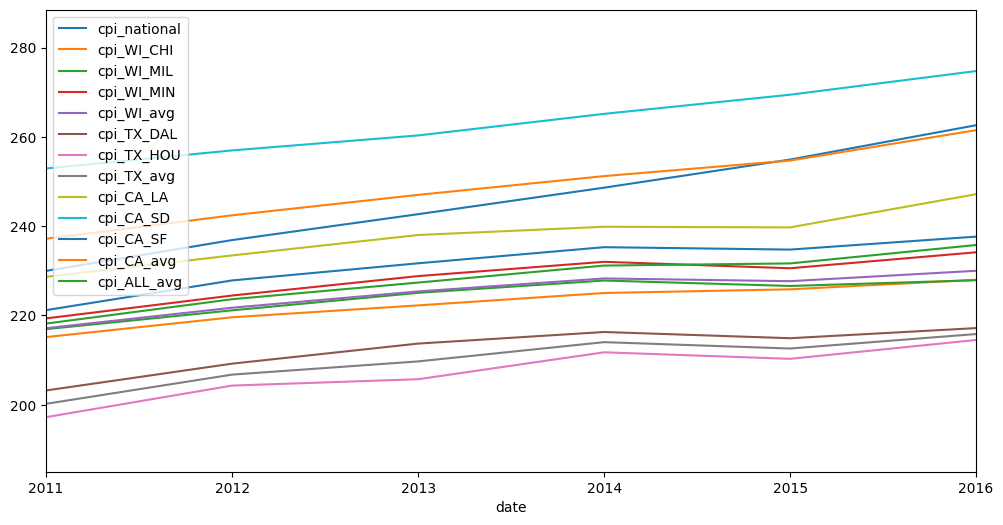

In [7]:
ax = df_CPI_ALL.plot(x='date', figsize=(12,6))

plt.autoscale(enable=True, tight=True)
ax.set_ylim(bottom=185, top=df_CPI_ALL['cpi_CA_SD'].max() * 1.05)
plt.show()

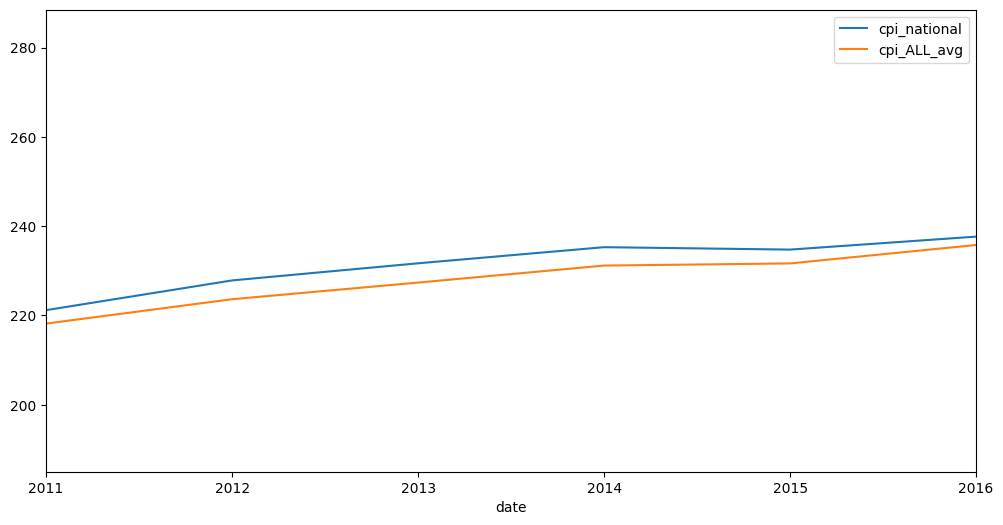

In [8]:
    # cpi_national (retrieved directly from FRED) and the derived cpi_ALL_avg shows clear correlation
ax = df_CPI_ALL[['date', 'cpi_national', 'cpi_ALL_avg']].plot(x='date', figsize=(12,6))
plt.autoscale(enable=True, tight=True)
ax.set_ylim(bottom=185, top=df_CPI_ALL['cpi_CA_SD'].max() * 1.05)
plt.show()

In [9]:
df_CPI_ALL.to_csv('../Data/Derived_data/CPI_ALL.csv', index=False)